# **Deep Learning Project: Street View Housing Number Digit Recognition**

# **Marks: 60**

--------------
## **Context**
--------------

One of the most interesting tasks in deep learning is to recognize objects in natural scenes. The ability to process visual information using machine learning algorithms can be very useful as demonstrated in various applications.

The SVHN dataset contains over 600,000 labeled digits cropped from street-level photos. It is one of the most popular image recognition datasets. It has been used in neural networks created by Google to improve the map quality by automatically transcribing the address numbers from a patch of pixels. The transcribed number with a known street address helps pinpoint the location of the building it represents.

----------------
## **Objective**
----------------

Our objective is to predict the number depicted inside the image by using Artificial or Fully Connected Feed Forward Neural Networks and Convolutional Neural Networks. We will go through various models of each and finally select the one that is giving us the best performance.

-------------
## **Dataset**
-------------
Here, we will use a subset of the original data to save some computation time. The dataset is provided as a .h5 file. The basic preprocessing steps have been applied on the dataset.

## **Mount the drive**

Let us start by mounting the Google drive. You can run the below cell to mount the Google drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Importing the necessary libraries**

In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 598.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 103.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.0 MB/s eta 0:00:00


In [ ]:
!pip install tables

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.9/398.9 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.1/506.1 kB 28.7 MB/s eta 0:00:00


In [ ]:
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix

import keras
# Keras Sequential Model
from tensorflow.keras.models import Sequential

# Importing all the different layers and optimizers
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Activation, LeakyReLU, GlobalAveragePooling2D

# Input
from tensorflow.keras import Input
from tensorflow.keras.utils import to_categorical

import random

from tensorflow.keras.optimizers import Adam


**Let us check the version of tensorflow.**

In [ ]:
!pip show tensorflow

Name: tensorflow
Version: 2.19.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, requests, setuptools, six, tensorboard, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: 


## **Load the dataset**

- Let us now load the dataset that is available as a .h5 file.
- Split the data into the train and the test dataset.

In [ ]:
with h5py.File('/content/drive/MyDrive/MIT/Final_Projects/SVHN_single_grey1.h5', 'r') as hf:
    print("File keys>", list(hf.keys()))
    X_train = np.array(hf['X_train'])
    y_train = np.array(hf['y_train'])
    X_test = np.array(hf['X_test'])
    y_test = np.array(hf['y_test'])

File keys> ['X_test', 'X_train', 'X_val', 'y_test', 'y_train', 'y_val']


Check the number of images in the training and the testing dataset.

In [ ]:
print(f"Number of training Images: {len(X_train)}", f"Number of testing Images: {len(X_test)}", sep='\n')

Number of training Images: 42000
Number of testing Images: 18000


**Observation:**\
There are **42,000** images in the **training** set, as well as **18,000** in the **test** set

## **Visualizing images**

- Use X_train to visualize the first 10 images.
- Use Y_train to print the first 10 labels.

In [ ]:
# Defining the display function to reuse it, if necessary
def display_head(X, y, qtd=10):
    plt.figure(figsize=(15, 2))
    for i in range(qtd):
        plt.subplot(1, qtd, i + 1)
        plt.imshow(X[i])
        plt.title(f"Label: {y[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

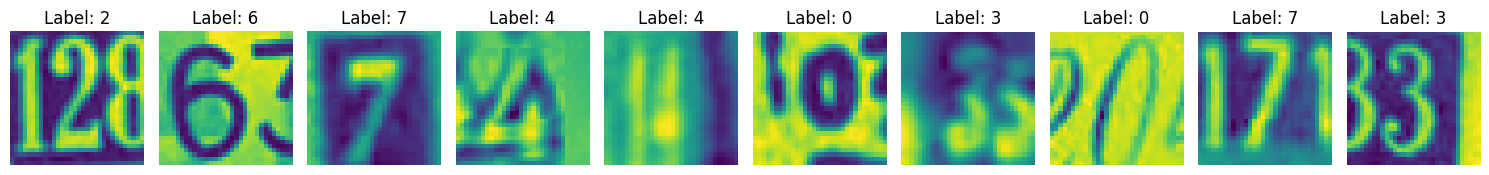

In [ ]:
display_head(X_train, y_train)

## **Data preparation**

- Print the shape and the array of pixels for the first image in the training dataset.
- Normalize the train and the test dataset by dividing by 255.
- Print the new shapes of the train and the test dataset.
- One-hot encode the target variable.

In [ ]:
# Checking images shape
print("Images shape:", X_train[0].shape)

Images shape: (32, 32)


In [ ]:
# Checking pixels for the first image
for pixel in X_train[0].flatten():
    print(pixel, end=" ")

33.0704 30.2601 26.852 25.8844 28.5421 33.1673 33.9069 31.277 27.3313 23.9556 21.3518 22.5258 24.2868 31.2322 37.2917 38.1776 30.8902 24.4887 27.983 23.3641 19.7774 23.0159 24.7168 24.9941 27.5701 38.5474 52.8341 65.9037 73.5609 71.4471 58.2204 42.9939 25.2283 25.5533 29.9765 40.96 54.0358 60.7317 57.5965 47.9611 33.0103 24.3362 24.3793 33.1997 44.1339 61.1815 80.5278 86.1744 79.7621 66.5893 47.4926 29.7548 21.8804 22.9943 25.2822 26.6303 39.7923 64.9531 91.0815 108.8795 113.6079 113.0209 103.3639 84.2949 26.2775 22.6137 40.4763 69.6815 91.8381 101.2887 97.0719 72.8832 41.1944 23.0975 32.0319 55.8077 82.2242 104.4069 113.9329 116.5197 117.7646 111.6512 83.8758 53.9974 32.4664 22.3256 23.4179 32.2491 61.2093 99.8526 117.9217 117.4272 110.1398 113.3028 121.775 115.4228 32.3478 26.8044 51.4383 87.5396 106.8321 113.38 104.0219 70.8233 38.3626 24.8415 46.8948 82.9853 107.8966 112.3738 97.9068 93.7331 108.9227 119.4009 116.9173 89.2128 50.6665 25.2544 25.3899 53.6383 92.8703 121.9661 121.155

### **Normalize the train and the test data**

In [ ]:
# Normalizing the features
X_train = X_train / 255.0
X_test = X_test / 255.0

Print the shapes of Training and Test data

In [ ]:
# Checking images shape
print("Train Images shape:", X_train.shape)
print("Test Images shape:", X_test.shape)

Train Images shape: (42000, 32, 32)
Test Images shape: (18000, 32, 32)


### **One-hot encode output**

In [ ]:
# Checking dimensions before encoding
y_test.ndim

1

In [ ]:
# Encoding the labels to predict number from 0 to 9
y_train_encoded = to_categorical(y_train, num_classes=10)
# Checking the new shape
print("'y' format after one-hot:", y_train_encoded.shape)

'y' format after one-hot: (42000, 10)


In [ ]:
# Comparing old with new labels
print("'y' original:", y_train[0])
print("'y' encoded:", y_train_encoded[0])

'y' original: 2
'y' encoded: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
# Doing the same to the test dataset
y_test_encoded = to_categorical(y_test, num_classes=10)
print("'y' format after one-hot:", y_test_encoded.shape)
print("'y' original:", y_test[0])
print("'y' encoded:", y_test_encoded[0])

'y' format after one-hot: (18000, 10)
'y' original: 1
'y' encoded: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
# Flattening the training images
X_train_flat = X_train.reshape(X_train.shape[0], 32*32)

In [ ]:
# Flattening the test images
X_test_flat = X_test.reshape(X_test.shape[0], 32*32)

In [ ]:
print("Train Images shape:", X_train_flat.shape)
print("Test Images shape:", X_test_flat.shape)

Train Images shape: (42000, 1024)
Test Images shape: (18000, 1024)


**Observation:**
* Both training and test set images were flattened to a single dimension, where each image is now represented by a row of pixel values.
* Labels in both sets were one-hot encoded to represent class probabilities.

Image shape changed from `(n_images, 32, 32)` to `(n_images, 1024)`, and label shape from `(n_labels, 1)` to `(n_labels, 10)`

## **Model Building**

Now that we have done the data preprocessing, let's build an ANN model.

### Fix the seed for random number generators

In [ ]:
# Fixing seeds
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

### **Model Architecture**
- Write a function that returns a sequential model with the following architecture:
 - First hidden layer with **64 nodes and the relu activation** and the **input shape = (1024, )**
 - Second hidden layer with **32 nodes and the relu activation**
 - Output layer with **activation as 'softmax' and number of nodes equal to the number of classes, i.e., 10**
 - Compile the model with the **loss equal to categorical_crossentropy, optimizer equal to Adam(learning_rate = 0.001), and metric equal to 'accuracy'**. Do not fit the model here, just return the compiled model.
- Call the nn_model_1 function and store the model in a new variable.
- Print the summary of the model.
- Fit on the train data with a **validation split of 0.2, batch size = 128, verbose = 1, and epochs = 20**. Store the model building history to use later for visualization.

### **Build and train an ANN model as per the above mentioned architecture.**

In [ ]:
# Building first ANN model architecture
def nn_model_1():
  model = Sequential([
      Input(shape=(1024,)),
      Dense(64, activation='relu'),
      Dense(32, activation='relu'),
      Dense(10, activation='softmax')
  ])

  model.compile(
      loss='categorical_crossentropy',
      optimizer=Adam(learning_rate=0.001),
      metrics=['accuracy']
  )
  return model


In [ ]:
# Building the model and checking the layers
ann_model = nn_model_1()
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          65,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 68,010 (265.66 KB)

 Trainable params: 68,010 (265.66 KB)

 Non-trainable params: 0 (0.00 B)

Fit on the train data with a validation split of 0.2, batch size = 128, verbose = 1, and epochs = 20. Store the model building history to use later for visualization.

In [ ]:
# Training the model and storing it's history
ann_1_history = ann_model.fit(x = X_train_flat, y = y_train_encoded, validation_split=0.2, batch_size=128, verbose=1, epochs=20)

Epoch 1/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1073 - loss: 2.3092 - val_accuracy: 0.1632 - val_loss: 2.2677
Epoch 2/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1778 - loss: 2.2184 - val_accuracy: 0.2912 - val_loss: 2.0361
Epoch 3/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3392 - loss: 1.9184 - val_accuracy: 0.4385 - val_loss: 1.6545
Epoch 4/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4624 - loss: 1.6101 - val_accuracy: 0.5181 - val_loss: 1.4750
Epoch 5/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5249 - loss: 1.4636 - val_accuracy: 0.5407 - val_loss: 1.4091
Epoch 6/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5542 - loss: 1.3851 - val_accuracy: 0.5593 - val_loss: 1.3627
Epoch 7/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5763 - loss: 1.3323 - val_accuracy: 0.5877 - val_loss: 1.3038
Epoch 8/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5946 - loss: 1.2852 - val_accuracy: 0.

### **Plot the Training and Validation Accuracies and write down your Observations.**

In [ ]:
# Defining the accuracy plot for later use
def plot_train_val_acc(history):
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['val_accuracy'])
  plt.title('Model accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Validation'], loc='upper left')
  plt.show()

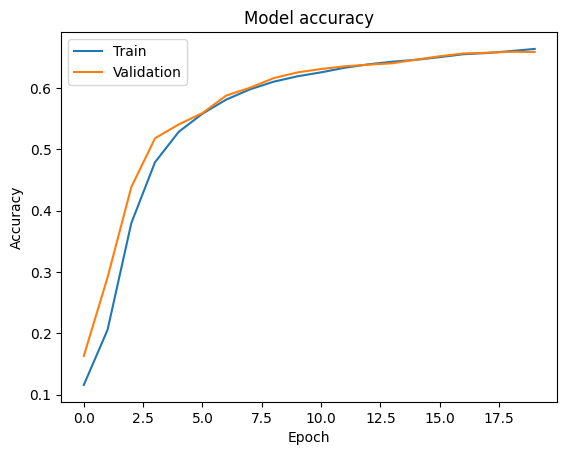

In [ ]:
plot_train_val_acc(ann_1_history) # plotting model history

**Observations:**

Our model showed an accuracy of **0.6626** and loss of **1.0948**,
Using `validation_split=0.2, batch_size=128, verbose=1, epochs=20`

The model does not exhibit signs of overfitting or underfitting, but its accuracy remains relatively low.

Since the model continues to improve toward the final epochs without showing signs of overfitting, **increasing the number of epochs** may be a good strategy to further enhance its performance.

Let's build one more model with higher complexity and see if we can improve the performance of the model.

First, we need to clear the previous model's history from the Keras backend. Also, let's fix the seed again after clearing the backend.

In [ ]:
# Clearing the session backend to train a new model
keras.backend.clear_session()

In [ ]:
# Fixing the seeds
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

### **Second Model Architecture**
- Write a function that returns a sequential model with the following architecture:
 - First hidden layer with **256 nodes and the relu activation** and the **input shape = (1024, )**
 - Second hidden layer with **128 nodes and the relu activation**
 - Add the **Dropout layer with the rate equal to 0.2**
 - Third hidden layer with **64 nodes and the relu activation**
 - Fourth hidden layer with **64 nodes and the relu activation**
 - Fifth hidden layer with **32 nodes and the relu activation**
 - Add the **BatchNormalization layer**
 - Output layer with **activation as 'softmax' and number of nodes equal to the number of classes, i.e., 10**
 -Compile the model with the **loss equal to categorical_crossentropy, optimizer equal to Adam(learning_rate = 0.0005), and metric equal to 'accuracy'**. Do not fit the model here, just return the compiled model.
- Call the nn_model_2 function and store the model in a new variable.
- Print the summary of the model.
- Fit on the train data with a **validation split of 0.2, batch size = 128, verbose = 1, and epochs = 30**. Store the model building history to use later for visualization.

### **Build and train the new ANN model as per the above mentioned architecture**

In [ ]:
# Defining the second model architecture
def nn_model_2():
  model = Sequential([
      Input(shape=(1024,)),
      Dense(256, activation='relu'),
      Dense(128, activation='relu'),
      Dropout(0.2), # Randomly deactivating neurons to prevent overfitting
      Dense(64, activation='relu'), # Increasing the number of activation layers
      Dense(64, activation='relu'),
      Dense(32, activation='relu'),
      BatchNormalization(), # Using batch normalization for a faster training and increasing stability
      Dense(10, activation='softmax')
  ])

  model.compile(
      loss='categorical_crossentropy',
      optimizer=Adam(learning_rate=0.0005), # Lower learning rate to prevent overfitting
      metrics=['accuracy']
  )
  return model

In [ ]:
# Building the model and checking the architecture
ann_model2 = nn_model_2()
ann_model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         262,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 310,250 (1.18 MB)

 Trainable params: 310,186 (1.18 MB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
# Training again with higher number of epochs
ann_2_history = ann_model2.fit(x = X_train_flat, y = y_train_encoded, validation_split=0.2, batch_size=128, verbose=1, epochs=30)

Epoch 1/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.1005 - loss: 2.4734 - val_accuracy: 0.0969 - val_loss: 2.3177
Epoch 2/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1117 - loss: 2.3051 - val_accuracy: 0.1889 - val_loss: 2.2530
Epoch 3/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2688 - loss: 2.0309 - val_accuracy: 0.4074 - val_loss: 1.7327
Epoch 4/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4799 - loss: 1.5304 - val_accuracy: 0.5827 - val_loss: 1.2792
Epoch 5/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5640 - loss: 1.3189 - val_accuracy: 0.6117 - val_loss: 1.2009
Epoch 6/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6169 - loss: 1.1803 - val_accuracy: 0.6543 - val_loss: 1.0786
Epoch 7/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6455 - loss: 1.1044 - val_accuracy: 0.6752 - val_loss: 1.0263
Epoch 8/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6610 - loss: 1.0617 - val_accuracy: 0.

### **Plot the Training and Validation Accuracies and write down your Observations.**

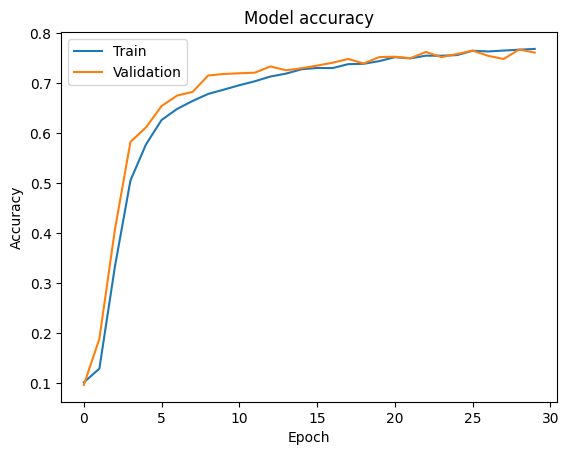

In [ ]:
plot_train_val_acc(ann_2_history) # Plotting model history

**Observations:**

The second model showed a significant improvement in accuracy (**\~0.77**) and a reduction in loss (**\~0.73**), still without signs of overfitting or underfitting.

The curves are approaching a plateau, indicating convergence. Although increasing the number of epochs might lead to a slight improvement, it is probably not worth the additional computational cost.

## **Predictions on the test data**

- Make predictions on the test set using the second model.
- Print the obtained results using the classification report and the confusion matrix.
- Final observations on the obtained results.

In [ ]:
y_pred = ann_model2.predict(X_test_flat)

563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


**Note:** Earlier, we noticed that each entry of the target variable is a one-hot encoded vector but to print the classification report and confusion matrix, we must convert each entry of y_test to a single label.

In [ ]:
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_encoded, axis=1)

### **Print the classification report and the confusion matrix for the test predictions. Write your observations on the final results.**

In [ ]:

print(classification_report(y_true, y_pred_classes))


              precision    recall  f1-score   support

           0       0.74      0.81      0.77      1814
           1       0.73      0.83      0.78      1828
           2       0.78      0.77      0.77      1803
           3       0.78      0.68      0.73      1719
           4       0.80      0.83      0.81      1812
           5       0.75      0.68      0.71      1768
           6       0.74      0.78      0.76      1832
           7       0.88      0.71      0.78      1808
           8       0.63      0.78      0.70      1812
           9       0.83      0.70      0.76      1804

    accuracy                           0.76     18000
   macro avg       0.77      0.76      0.76     18000
weighted avg       0.77      0.76      0.76     18000



In [ ]:
# Defining confusion matrix plot for later use
def plot_confusion_matrix(y_true, y_pred):
  conf_matrix = confusion_matrix(y_true, y_pred_classes)
  plt.figure(figsize=(5, 4))
  sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
  plt.xlabel('Predicted Labels')
  plt.ylabel('True Labels')
  plt.title('Confusion Matrix')
  plt.show()

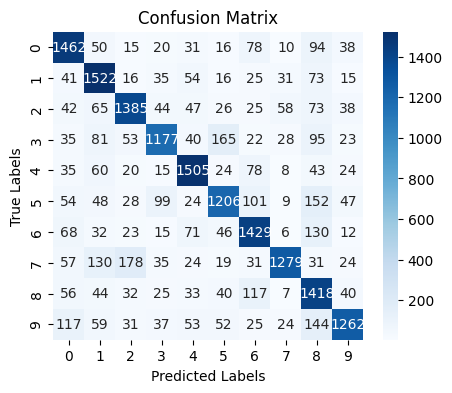

In [ ]:
plot_confusion_matrix(y_true, y_pred)

**Final Observations:**

Our model achieved **77%** accuracy on the testing set. Although this is an improvement over the first model, it is still relatively low for this task.

The confusion matrix indicates that the model tends to confuse digits with similar shapes.

## **Using Convolutional Neural Networks**

### **Load the dataset again and split the data into the train and the test dataset.**

In [ ]:
# Loding the files
with h5py.File('/content/drive/MyDrive/MIT/Final_Projects/SVHN_single_grey1.h5', 'r') as hf:
    print("File keys>", list(hf.keys()))
    X_train_CNN = np.array(hf['X_train'][:])
    y_train_CNN = np.array(hf['y_train'][:])
    X_test_CNN = np.array(hf['X_test'][:])
    y_test_CNN = np.array(hf['y_test'][:])

File keys> ['X_test', 'X_train', 'X_val', 'y_test', 'y_train', 'y_val']


Check the number of images in the training and the testing dataset.

In [ ]:
print("Number of images in training set:", len(X_train_CNN))

Number of images in training set: 42000


In [ ]:
print("Number of images in training set:", len(X_test_CNN))

Number of images in training set: 18000


**Observation:**

Number of images in training set: **42000**\
Number of images in training set: **18000**



## **Data preparation**

- Print the shape and the array of pixels for the first image in the training dataset.
- Reshape the train and the test dataset because we always have to give a 4D array as input to CNNs.
- Normalize the train and the test dataset by dividing by 255.
- Print the new shapes of the train and the test dataset.
- One-hot encode the target variable.

In [ ]:
# Checking images shape
print("Images shape:", X_train_CNN[0].shape)

Images shape: (32, 32)


In [ ]:
# First image pixel's array
for pixel in X_train_CNN[0].flatten():
    print(pixel, end=" ")

33.0704 30.2601 26.852 25.8844 28.5421 33.1673 33.9069 31.277 27.3313 23.9556 21.3518 22.5258 24.2868 31.2322 37.2917 38.1776 30.8902 24.4887 27.983 23.3641 19.7774 23.0159 24.7168 24.9941 27.5701 38.5474 52.8341 65.9037 73.5609 71.4471 58.2204 42.9939 25.2283 25.5533 29.9765 40.96 54.0358 60.7317 57.5965 47.9611 33.0103 24.3362 24.3793 33.1997 44.1339 61.1815 80.5278 86.1744 79.7621 66.5893 47.4926 29.7548 21.8804 22.9943 25.2822 26.6303 39.7923 64.9531 91.0815 108.8795 113.6079 113.0209 103.3639 84.2949 26.2775 22.6137 40.4763 69.6815 91.8381 101.2887 97.0719 72.8832 41.1944 23.0975 32.0319 55.8077 82.2242 104.4069 113.9329 116.5197 117.7646 111.6512 83.8758 53.9974 32.4664 22.3256 23.4179 32.2491 61.2093 99.8526 117.9217 117.4272 110.1398 113.3028 121.775 115.4228 32.3478 26.8044 51.4383 87.5396 106.8321 113.38 104.0219 70.8233 38.3626 24.8415 46.8948 82.9853 107.8966 112.3738 97.9068 93.7331 108.9227 119.4009 116.9173 89.2128 50.6665 25.2544 25.3899 53.6383 92.8703 121.9661 121.155

Reshape the dataset to be able to pass them to CNNs. Remember that we always have to give a 4D array as input to CNNs

In [ ]:
# Reshaping the dataset and reducing the colors dimension
X_train_CNN = X_train_CNN.reshape(len(X_train_CNN), 32, 32, 1)
X_test_CNN = X_test_CNN.reshape(len(X_test_CNN), 32, 32, 1)

Normalize inputs from 0-255 to 0-1

In [ ]:
# Normalizing inputs
X_train_CNN = X_train_CNN / 255.0
X_test_CNN = X_test_CNN / 255.0

Print New shape of Training and Test

In [ ]:
# Checking shape of training and test sets after transformations
print(X_train_CNN.shape, X_test_CNN.shape, sep='\n')

(42000, 32, 32, 1)
(18000, 32, 32, 1)


### **One-hot encode the labels in the target variable y_train and y_test.**

In [ ]:
y_test_CNN = to_categorical(y_test_CNN, num_classes=10)
y_train_CNN = to_categorical(y_train_CNN, num_classes=10)

**Observation:**

The input datasets (training and test) were reshaped by reducing the color channels **from RGB to grayscale**, and normalized to a range between **0 and 1**.

The output labels (training and testing) were one-hot encoded to represent the probability distribution across all classes.


## **Model Building**

Now that we have done data preprocessing, let's build a CNN model.
Fix the seed for random number generators

In [ ]:
# Fixing the seeds
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

### **Model Architecture**
- **Write a function** that returns a sequential model with the following architecture:
 - First Convolutional layer with **16 filters and the kernel size of 3x3**. Use the **'same' padding** and provide the **input shape = (32, 32, 1)**
 - Add a **LeakyRelu layer** with the **slope equal to 0.1**
 - Second Convolutional layer with **32 filters and the kernel size of 3x3 with 'same' padding**
 - Another **LeakyRelu** with the **slope equal to 0.1**
 - A **max-pooling layer** with a **pool size of 2x2**
 - **Flatten** the output from the previous layer
 - Add a **dense layer with 32 nodes**
 - Add a **LeakyRelu layer with the slope equal to 0.1**
 - Add the final **output layer with nodes equal to the number of classes, i.e., 10** and **'softmax' as the activation function**
 - Compile the model with the **loss equal to categorical_crossentropy, optimizer equal to Adam(learning_rate = 0.001), and metric equal to 'accuracy'**. Do not fit the model here, just return the compiled model.
- Call the function cnn_model_1 and store the output in a new variable.
- Print the summary of the model.
- Fit the model on the training data with a **validation split of 0.2, batch size = 32, verbose = 1, and epochs = 20**. Store the model building history to use later for visualization.

### **Build and train a CNN model as per the above mentioned architecture.**

In [ ]:
# Defining the first CNN model architecture
def cnn_model_1():
  model = Sequential([
      Input(shape=(32, 32, 1)),
      Conv2D(16, kernel_size=(3, 3), padding='same'),
      LeakyReLU(negative_slope=0.1),
      Conv2D(32, kernel_size=(3, 3), padding='same'),
      LeakyReLU(negative_slope=0.1),
      MaxPooling2D(pool_size=(2, 2)),
      Flatten(),
      Dense(32, activation='relu'),
      LeakyReLU(negative_slope=0.1),
      Dense(10, activation='softmax')
  ])
  model.compile(
      loss='categorical_crossentropy',
      optimizer=Adam(learning_rate=0.001),
      metrics=['accuracy']
  )
  return model

In [ ]:
# Building and checking the first CNN model
CNN_model = cnn_model_1()
CNN_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 32, 32, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │         262,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 267,306 (1.02 MB)

 Trainable params: 267,306 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training the first CNN model
cnn_1_history = CNN_model.fit(x=X_train_CNN, y=y_train_CNN, validation_split=0.2, batch_size=32, verbose=1, epochs=20)

Epoch 1/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.3849 - loss: 1.7137 - val_accuracy: 0.8068 - val_loss: 0.6616
Epoch 2/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8341 - loss: 0.5804 - val_accuracy: 0.8338 - val_loss: 0.5845
Epoch 3/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8650 - loss: 0.4689 - val_accuracy: 0.8538 - val_loss: 0.5304
Epoch 4/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8788 - loss: 0.4068 - val_accuracy: 0.8588 - val_loss: 0.5098
Epoch 5/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8942 - loss: 0.3586 - val_accuracy: 0.8606 - val_loss: 0.5247
Epoch 6/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9071 - loss: 0.3201 - val_accuracy: 0.8589 - val_loss: 0.5272
Epoch 7/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9177 - loss: 0.2875 - val_accuracy: 0.8583 - val_loss: 0.5394
Epoch 8/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9240 - loss: 0.26

### **Plot the Training and Validation Accuracies and Write your observations.**

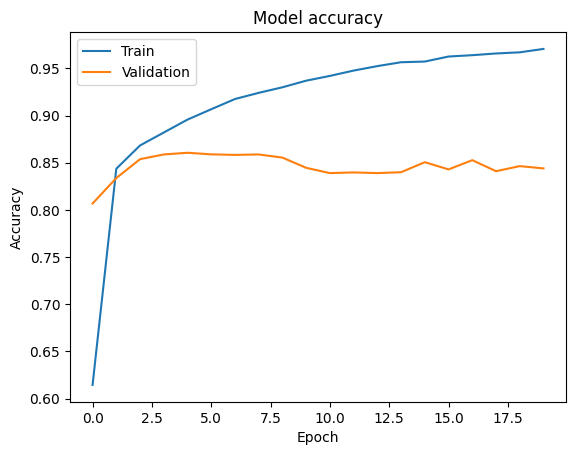

In [ ]:
plot_train_val_acc(cnn_1_history)

**Observations:**

The training history plot shows significantly **higher accuracy** on the training set compared to the validation set, clearly indicating that the **model struggles to generalize**.

The simultaneous increase in accuracy and validation loss further suggests **overfitting**

Let's build another model and see if we can get a better model with generalized performance.

First, we need to clear the previous model's history from the Keras backend. Also, let's fix the seed again after clearing the backend.

In [ ]:
# Clearing keras backend session to train a new model
keras.backend.clear_session()

In [ ]:
# Fixing the seeds again
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

### **Second Model Architecture**

- Write a function that returns a sequential model with the following architecture:
 - First Convolutional layer with **16 filters and the kernel size of 3x3**. Use the **'same' padding** and provide the **input shape = (32, 32, 1)**
 - Add a **LeakyRelu layer** with the **slope equal to 0.1**
 - Second Convolutional layer with **32 filters and the kernel size of 3x3 with 'same' padding**
 - Add **LeakyRelu** with the **slope equal to 0.1**
 - Add a **max-pooling layer** with a **pool size of 2x2**
 - Add a **BatchNormalization layer**
 - Third Convolutional layer with **32 filters and the kernel size of 3x3 with 'same' padding**
 - Add a **LeakyRelu layer with the slope equal to 0.1**
 - Fourth Convolutional layer **64 filters and the kernel size of 3x3 with 'same' padding**
 - Add a **LeakyRelu layer with the slope equal to 0.1**
 - Add a **max-pooling layer** with a **pool size of 2x2**
 - Add a **BatchNormalization layer**
 - **Flatten** the output from the previous layer
 - Add a **dense layer with 32 nodes**
 - Add a **LeakyRelu layer with the slope equal to 0.1**
 - Add a **dropout layer with the rate equal to 0.5**
 - Add the final **output layer with nodes equal to the number of classes, i.e., 10** and **'softmax' as the activation function**
 - Compile the model with the **categorical_crossentropy loss, adam optimizers (learning_rate = 0.001), and metric equal to 'accuracy'**. Do not fit the model here, just return the compiled model.
- Call the function cnn_model_2 and store the model in a new variable.
- Print the summary of the model.
- Fit the model on the train data with a **validation split of 0.2, batch size = 128, verbose = 1, and epochs = 30**. Store the model building history to use later for visualization.

### **Build and train the second CNN model as per the above mentioned architecture.**

In [ ]:
# Defining the second CNN model architecure
def cnn_model_2():
  model = Sequential([
      Input(shape=(32, 32, 1)),
      Conv2D(16, kernel_size=(3, 3), padding='same'),
      LeakyReLU(negative_slope=0.1),
      Conv2D(32, kernel_size=(3, 3), padding='same'),
      LeakyReLU(negative_slope=0.1),
      MaxPooling2D(pool_size=(2, 2)),
      BatchNormalization(),
      Conv2D(32, kernel_size=(3, 3), padding='same'),
      LeakyReLU(negative_slope=0.1),
      Conv2D(64, kernel_size=(3, 3), padding='same'),
      LeakyReLU(negative_slope=0.1),
      MaxPooling2D(pool_size=(2, 2)),
      BatchNormalization(),
      Flatten(),
      Dense(32, activation='relu'),
      LeakyReLU(negative_slope=0.1),
      Dropout(0.5),
      Dense(10, activation='softmax')
  ])
  model.compile(
      loss='categorical_crossentropy',
      optimizer=Adam(learning_rate=0.001),
      metrics=['accuracy']
  )
  return model

In [ ]:
# Building and checking the second CNN model
CNN_2_model = cnn_model_2()
CNN_2_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 32, 32, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 16, 16, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 8, 8, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │         131,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_4 (LeakyReLU)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 164,362 (642.04 KB)

 Trainable params: 164,170 (641.29 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# Checking the features to guarantee the right shape
print(X_train_CNN.shape)
print(y_train_CNN.shape)

(42000, 32, 32, 1)
(42000, 10)


In [ ]:
cnn_2_history = CNN_2_model.fit(x=X_train_CNN, y=y_train_CNN, validation_split=0.2, batch_size=128, verbose=1, epochs=30)

Epoch 1/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.1105 - loss: 2.3328 - val_accuracy: 0.1067 - val_loss: 2.9063
Epoch 2/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.2866 - loss: 1.8872 - val_accuracy: 0.6912 - val_loss: 1.0047
Epoch 3/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.6263 - loss: 1.0698 - val_accuracy: 0.8505 - val_loss: 0.5207
Epoch 4/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.7289 - loss: 0.7928 - val_accuracy: 0.8699 - val_loss: 0.4534
Epoch 5/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.7767 - loss: 0.6805 - val_accuracy: 0.8763 - val_loss: 0.4224
Epoch 6/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.8030 - loss: 0.5797 - val_accuracy: 0.8850 - val_loss: 0.4021
Epoch 7/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.8199 - loss: 0.5295 - val_accuracy: 0.8880 - val_loss: 0.3993
Epoch 8/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.8295 - loss: 0.5017 - 

### **Plot the Training and Validation accuracies and write your observations.**

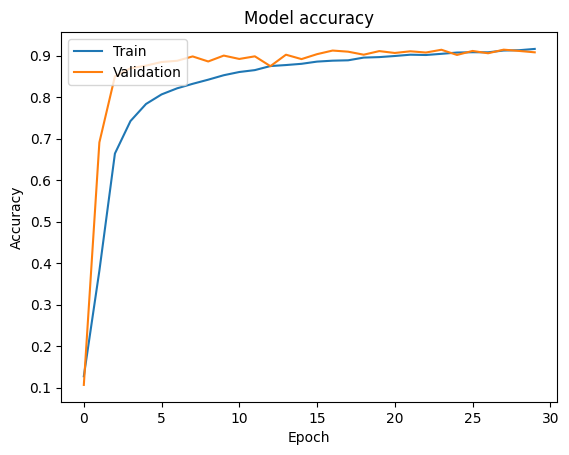

In [ ]:
plot_train_val_acc(cnn_2_history)

**Observations:**

The second CNN model demonstrates the **best performance** among all the models evaluated.\
The training history plot shows low variance between training and validation scores, indicating that the model **does not overfit** the training data.

## **Predictions on the test data**

- Make predictions on the test set using the second model.
- Print the obtained results using the classification report and the confusion matrix.
- Final observations on the obtained results.

### **Make predictions on the test data using the second model.**

In [ ]:
y_pred = CNN_2_model.predict(X_test_CNN)

563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


**Note:** Earlier, we noticed that each entry of the target variable is a one-hot encoded vector, but to print the classification report and confusion matrix, we must convert each entry of y_test to a single label.

In [ ]:
# Checking the testing features shape
print("Testing images shape: ", X_test_CNN.shape)
print("Testing labels shape: ", y_test_CNN.shape)

Testing images shape:  (18000, 32, 32, 1)
Testing labels shape:  (18000, 10)


In [ ]:
# Making predictions and printing the classification report
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_CNN, axis=1)

print(classification_report(y_true[:len(y_pred_classes)], y_pred_classes))

              precision    recall  f1-score   support

           0       0.94      0.93      0.93      1814
           1       0.84      0.94      0.89      1828
           2       0.92      0.93      0.92      1803
           3       0.87      0.89      0.88      1719
           4       0.92      0.93      0.92      1812
           5       0.88      0.93      0.91      1768
           6       0.92      0.89      0.91      1832
           7       0.95      0.91      0.93      1808
           8       0.93      0.86      0.90      1812
           9       0.93      0.87      0.90      1804

    accuracy                           0.91     18000
   macro avg       0.91      0.91      0.91     18000
weighted avg       0.91      0.91      0.91     18000



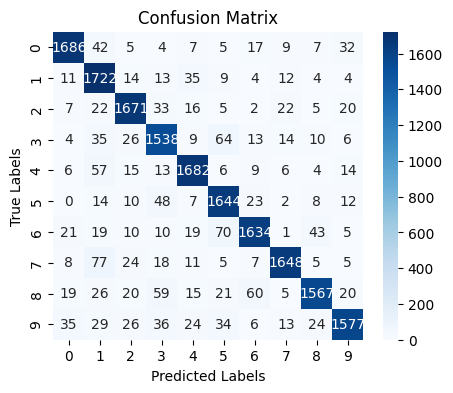

In [ ]:
# Plotting the confusion matrix
plot_confusion_matrix(y_true[:len(y_pred_classes)], y_pred_classes)

### **Write your final observations on the performance of the model on the test data.**

**Final Observations:**

## 🔍 Key Metrics

- **Overall Accuracy:**  
  The model achieved **91% accuracy** on the test dataset, reflecting strong generalization performance across all digit classes.

- **Precision:**  
  Average precision across all classes is **0.91**, indicating that when the model predicts a class, it is correct 91% of the time.

- **Recall:**  
  Also averages **0.91**, meaning the model is able to correctly identify 91% of the actual samples for each class.

- **F1-Score:**  
  Balanced F1-score of **0.91**, confirming that the model effectively balances precision and recall, making it reliable for real-world predictions.

  
---

## 📊 Confusion Matrix Highlights


- **Diagonal Dominance:**  
  The matrix is dominated by high values on the diagonal, indicating that **most predictions are correct**.

- **Low Off-Diagonal Values:**  
  There are relatively **few misclassifications**, but some confusion is observed between:
  - Class 3 and classes **5 & 6**
  - Class 1 and class **4**
  - Class 8 and classes **3 & 5**



---


## 💡 Insights

- The model **performs exceptionally well overall**, with balanced scores across most classes.
- **Class 1** may be suffering from false positives, and **class 3** may be harder to distinguish, possibly due to **visual similarities with other digits** or **less distinct training examples**.
- The model shows **strong generalization** with minimal overfitting signs.



---


## 📈 Recommended Next Steps

1. **Enhance Class Differentiation:**
    - Focus on **class 3 and class 1** by:
     - Adding more training samples
     - Applying **data augmentation**
     - Using **class-specific loss weighting**

2. **Tune the Model Architecture:**
   - Consider deeper or more complex CNN blocks.
   - Use **attention mechanisms** or **residual connections** to improve focus on subtle differences.

3. **Analyze Misclassifications:**
   - Investigate wrongly predicted samples (off-diagonal elements) to gain insight into recurring error patterns.
